In [2]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)
print("Running on:", DEVICE)

Running on: cuda


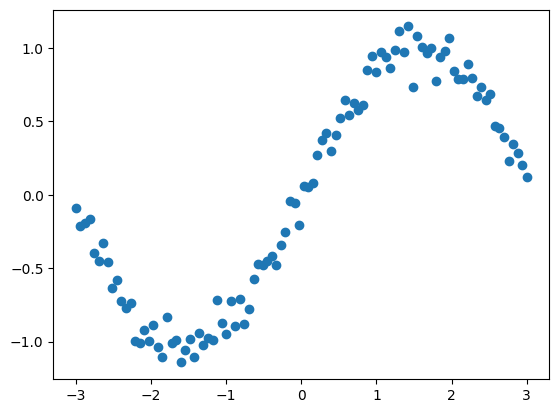

[np.float64(0.9032945639381899), np.float64(0.302438028591318), np.float64(0.21186231534876973), np.float64(0.1981220033943185), np.float64(0.19598232605594412), np.float64(0.19561404495578089), np.float64(0.19552896236574963), np.float64(0.19549716987611648), np.float64(0.19548023193407446), np.float64(0.1954699045728726), np.float64(0.19546337223075047), np.float64(0.1954592031418718), np.float64(0.1954565366717254), np.float64(0.19545483039362807), np.float64(0.19545373841518343), np.float64(0.19545303955492738), np.float64(0.19545259228525844), np.float64(0.19545230603280492), np.float64(0.1954521228312549), np.float64(0.195452005582266), np.float64(0.19545193054291357), np.float64(0.19545188251772802), np.float64(0.19545185178160931), np.float64(0.19545183211049338), np.float64(0.1954518195209791), np.float64(0.19545181146369003), np.float64(0.19545180630702497), np.float64(0.19545180300675935), np.float64(0.19545180089458938), np.float64(0.1954517995428006), np.float64(0.19545179

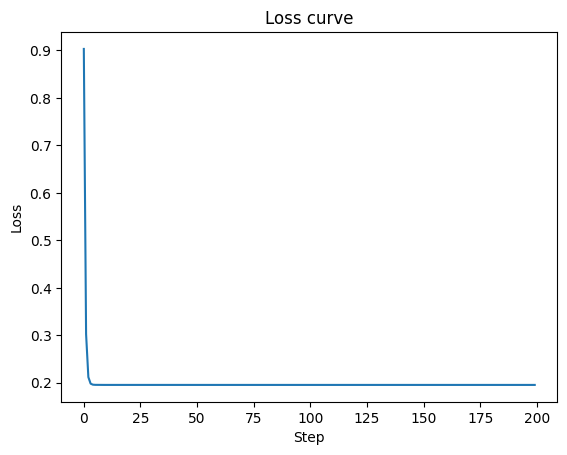

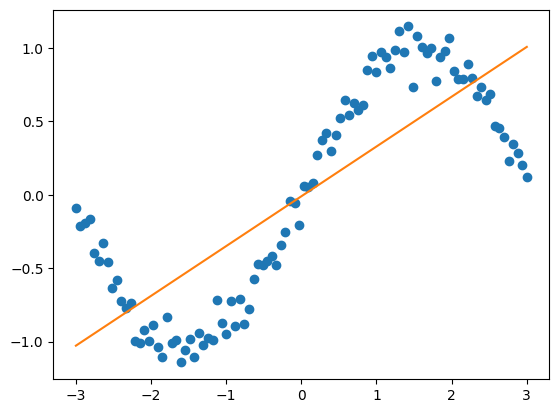

In [3]:
# TODO: Generate the toy data
x = np.linspace(-3, 3, 100) 
y = np.sin(x) + np.random.normal(scale = 0.1, size=100)  #small Gaussian noise (std=0.1)
plt.plot(x, y, 'o', label='toy data')
#   Plot it.
plt.show()

# TODO: Initialise w and b to small random values. 
w = np.random.normal(scale = 0.1)
b = np.random.normal(scale = 0.1)
#print(w)
#print(b)
# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
lr= 0.1
#   Record the loss at every step.
losses = []
for i in range(200):
    y_hat = w * x + b
    loss  = np.mean((y_hat - y) ** 2)    
    #print(loss)           # MSE
    dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
    db    = np.mean(2 * (y_hat - y))                # dLoss/db
    w    -= lr * dw
    b    -= lr * db
    losses.append(loss)
print(losses)

# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.
plt.plot(losses)
plt.title("Loss curve")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.show()

plt.plot(x, y, 'o')
plt.plot(x, y_hat, label='fitted line')
plt.show()
     

In [4]:
""" Student Reasoning — The single neuron 1. Derive dLoss/dw on paper and include a photo or the LaTeX in this 
cell — does it match the code? 2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting, 
and WHY can a single neuron never fit a sine wave, no matter how long you train?"""

' Student Reasoning — The single neuron 1. Derive dLoss/dw on paper and include a photo or the LaTeX in this \ncell — does it match the code? 2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting, \nand WHY can a single neuron never fit a sine wave, no matter how long you train?'

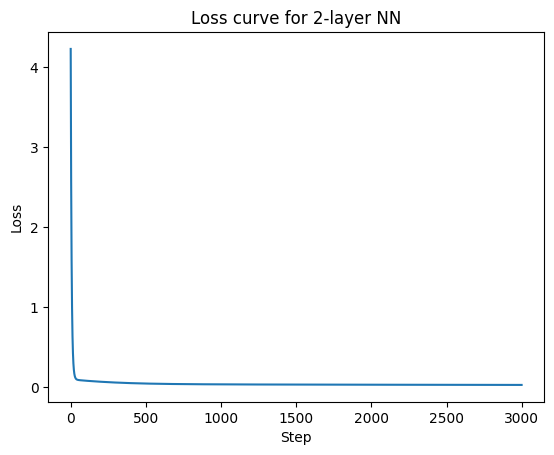

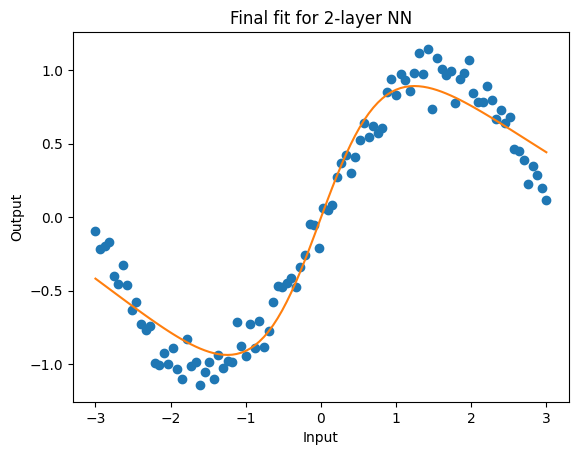

In [5]:
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)
x = x.reshape(-1, 1) 
y = y.reshape(-1, 1) 
W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5
W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5


# TODO: Forward pass (keep the intermediate values — you need them for backprop):
lr2 = 0.01
losses2 = []
for a in range(3000):
    # Forward pass
    z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
    h  = np.tanh(z1)        # activation
    y_hat2 = h @ W2 + b2     # output, shape (100, 1)
    loss2  = np.mean((y_hat2 - y) ** 2)
    

    # TODO: Backward pass (the chain rule, layer by layer):
    d_yhat = 2 * (y_hat2 - y) / len(y)
    dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
    dh  = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
    dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

    # TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
    #   record the loss.
    losses2.append(loss2)
    # Update parameters
    W2 -= lr2 * dW2
    b2 -= lr2 * db2
    W1 -= lr2 * dW1
    b1 -= lr2 * db1

# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
plt.plot(losses2)
plt.title("Loss curve for 2-layer NN")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.show()

plt.plot(x, y, 'o')
plt.plot(x, y_hat2)
plt.title("Final fit for 2-layer NN")
plt.xlabel("Input")
plt.ylabel("Output")
plt.show()